In [14]:
from typing_extensions import TypedDict, Literal
from typing import List
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model("openai:gpt-4o")

greetingMsg_llm = llm.invoke("준비됬나?")
print(greetingMsg_llm.content)


네, 준비되었습니다! 무엇을 도와드릴까요?


In [ ]:
class State(TypedDict) :
    document : str              # 문서
    summary : str               # 요약
    sentiment : str             # 감정분석
    key_points : str            # 핵심사항
    recommendation : str        # 권장사항
    final_analysis : str        # 최종분석
    translate_kor : str         # 번역본본

In [ ]:
# 요약
def node_get_summary(state : State):
    res = llm.invoke(
        f"Write a 3-sentence summary of this document {state["document"]}"
    )

    return {
        "summary" : res.content
    }

# 감정 분석석
def node_get_sentiment(state : State):
    res = llm.invoke(
        f"Analyse the sentiment and tone of this document {state["document"]}"
    )

    return {
        "sentiment" : res.content
    }

# 핵심
def node_get_key_points(state : State):
    res = llm.invoke(
        f"List the 5 most important points of this document {state["document"]}"
    )

    return {
        "key_points" : res.content
    }

def node_get_recommendation(state : State) :
    res = llm.invoke(
        f"Based on the document, list 3 recommended next steps {state["document"]}"
    )    

    return {
        "recommendation" : res.content
    }

def node_get_final_analysis(state : State):
    # 존재하지 않는 state 를 참조하면서도 error 를 피하는 방법은 state.get("key", "alt") 이다.
    # 기본적으로는 state["key"] 에 해당하는 값을 가져오지만, 없다면, alt 를 가져온다.
    res = llm.invoke(
        f"""
            Give me an analysis of the following report

            DOCUMENT ANALYSIS REPORT
            ---------------------

            EXECUTIVE SUMMARY:
            {state["summary"]}

            SENTIMENT ANALYSIS:
            {state["sentiment"]}

            KEY POINTS :
            {state.get("key_points", "")}

            RECOMMENDATIONS :
            {state.get("recommendation", "N/A")}
        """
    )

    return {
        "final_analysis" : res.content
    }    

# 번역본
def node_translate_toKor(state:State):
    translation_toKor = llm.invoke(f" 다음 내용을 한글로 번역해줘 : {state["final_analysis"]} ")

    with open("./final_analysis_kor.md", "wt", encoding="utf-8") as file : 
        file.write(translation_toKor.content)    

    return{
        "translate_kor" : translation_toKor.content
    }


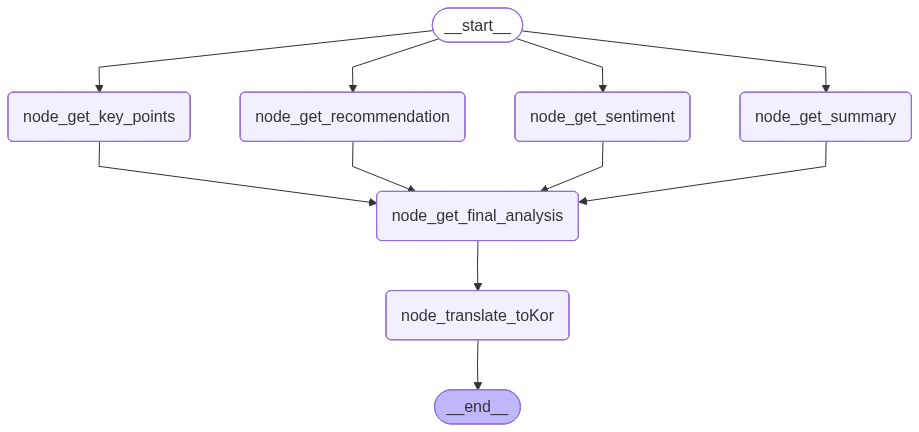

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("node_get_summary", node_get_summary)
graph_builder.add_node("node_get_sentiment", node_get_sentiment)
graph_builder.add_node("node_get_key_points", node_get_key_points)
graph_builder.add_node("node_get_recommendation", node_get_recommendation)
graph_builder.add_node("node_get_final_analysis", node_get_final_analysis)
graph_builder.add_node("node_translate_toKor", node_translate_toKor)

# 이렇게 한 노드에서 여러노드로 나가는경우 병렬 실행된다.
# 이것은 START 노드 에서 나갈때만 되는게 아니다. 모든 어떤 노드에서든 가능하다
# 다만 순서 보장이 없다.
# 그리고 완전 병렬이라기 보다 DAG 기반 스케줄링 이라고 한다.
# 병렬실행 (fan-out)
graph_builder.add_edge(START, "node_get_summary")
graph_builder.add_edge(START, "node_get_sentiment")
graph_builder.add_edge(START, "node_get_key_points")
graph_builder.add_edge(START, "node_get_recommendation")

# 병렬실행되었던 모든 노드가 한 노드로 모이게 되었을때
# 모든 입력 state 가 merge 된 이후, 다음 노드는 1번만 실행된다.
# merge 구조 (fan-in)
graph_builder.add_edge("node_get_summary", "node_get_final_analysis")
graph_builder.add_edge("node_get_sentiment", "node_get_final_analysis")
graph_builder.add_edge("node_get_key_points", "node_get_final_analysis")
graph_builder.add_edge("node_get_recommendation", "node_get_final_analysis")

graph_builder.add_edge("node_get_final_analysis", "node_translate_toKor")
graph_builder.add_edge("node_translate_toKor", END)

graph = graph_builder.compile()

graph

In [ ]:
with open("fed_transcript.md", "r", encoding="utf-8") as file :
    document = file.read()

# stream_mode = "updates" : 노드나 작업이 상태를 업데이트 할 때 발생하는 실시간 이벤트를 볼 수 있다.
# 어떤 노드가 state 를 업데이트 했는지, 어떤 state 를 업데이트 하였는지 알 수 있다.
for chunk in graph.stream({"document" : document}, stream_mode = "updates") :
    print(chunk, "\n")

{'node_get_summary': {'summary': 'The Federal Open Market Committee (FOMC) decided to lower the interest rate by a quarter percentage point to address rising downside risks to employment and moderately higher inflation, despite economic growth slowing and a softer labor market. While inflation has eased from its mid-2022 highs, it remains above the 2% target, driven by increased goods prices, though service disinflation persists. The FOMC emphasized their commitment to their dual mandate of maximum employment and stable prices, maintaining indepence from political influence, while continuously assessing policy based on evolving economic data and risks.'}} 

{'node_get_recommendation': {'recommendation': "Based on the document's content, here are three recommended next steps:\n\n1. **Monitor Economic Indicators Closely**: Given the current economic situation with moderate growth, elevated inflation, and a softening labor market, it's crucial for the Federal Reserve to closely monitor ke